<a href="https://colab.research.google.com/github/husthorng/Backpropagation_NN/blob/main/GA16_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1141husthorng
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
range_V

array([[3.600000e+02, 5.000000e-01, 1.280000e+02, 5.500000e-01,
        5.042100e+01, 9.959671e+02],
       [1.800000e+02, 3.000000e-01, 6.400000e+01, 3.500000e-01,
        3.178824e+01, 6.982139e+02]])

In [17]:
import numpy as np

# =========================
# Load NN model
# =========================
#下載W1W2.npz
#https://github.com/husthorng/Backpropagation_NN/blob/main/W1W2.npz

w = np.load("/content/drive/MyDrive/W1W2.npz")

W1 = w['W1']
W2 = w['W2']
max_v = w['max_v']
min_v = w['min_v']

range_V = np.stack((max_v, min_v), axis=0)

# =========================
# Activation
# =========================

def logistic(x):
    return 1/(1+np.exp(-x))

# =========================
# NN evaluation
# =========================

def evaluate(pop):

    x = (pop - range_V[1,0:4])/(range_V[0,0:4]-range_V[1,0:4])

    X = np.hstack((x, np.ones((x.shape[0],1))))

    h = logistic(X @ W1)

    H = np.hstack((h, np.ones((h.shape[0],1))))

    return logistic(H @ W2)


# =========================
# GA Parameters
# =========================

nvar = 4
npop = 250
gNr  = 30000

crossprob = 0.8
mutprob   = 0.02
mut_scale = 0.015

lambda_Ti = 0.1   # Ti weight

# =========================
# target
# =========================

target_Te = 760

CTe = (target_Te-min_v[5])/(max_v[5]-min_v[5])

# =========================
# initial population
# =========================

pop = min_v[0:4] + (max_v[0:4]-min_v[0:4]) * np.random.rand(npop,nvar)

OUT = evaluate(pop)

oldpop = pop.copy()
oldOUT = OUT.copy()

# bounds
low = min_v[0:4]
up  = max_v[0:4]
d = up - low

# =========================
# GA LOOP
# =========================

for gen in range(gNr):

    # -------------------------
    # tournament selection
    # -------------------------

    idx = np.random.randint(0,npop,(npop,2))

    fit1 = np.abs(oldOUT[idx[:,0],1]-CTe) + lambda_Ti*oldOUT[idx[:,0],0]
    fit2 = np.abs(oldOUT[idx[:,1],1]-CTe) + lambda_Ti*oldOUT[idx[:,1],0]

    win = np.where(fit1 < fit2, idx[:,0], idx[:,1])

    parent1 = oldpop[win]
    parent2 = oldpop[np.random.randint(0,npop,npop)]

    # -------------------------
    # crossover
    # -------------------------

    mask = np.random.rand(npop,nvar) < crossprob
    coeff = np.random.rand(npop,nvar)

    child = parent1.copy()

    child[mask] = (
        parent1[mask]*(1-coeff[mask]) +
        parent2[mask]*coeff[mask]
    )

    # -------------------------
    # mutation
    # -------------------------

    mutmask = np.random.rand(npop,nvar) < mutprob

    child += mutmask * (mut_scale * d * np.random.randn(npop,nvar))

    child = np.clip(child, low, up)

    pop = child

    # -------------------------
    # evaluate
    # -------------------------

    OUT = evaluate(pop)

    # -------------------------
    # fitness
    # -------------------------

    Te_err = np.abs(OUT[:,1]-CTe)
    Ti_val = OUT[:,0]

    fitness = Te_err + lambda_Ti*Ti_val

    new_idx = np.argmin(fitness)

    old_idx = np.random.randint(npop)

    old_fit = np.abs(oldOUT[old_idx,1]-CTe) + lambda_Ti*oldOUT[old_idx,0]

    if fitness[new_idx] < old_fit:
        oldpop[old_idx] = pop[new_idx]
        oldOUT[old_idx] = OUT[new_idx]

    # -------------------------
    # best solution
    # -------------------------

    best_fit = np.abs(oldOUT[:,1]-CTe) + lambda_Ti*oldOUT[:,0]

    idx_best = np.argmin(best_fit)

    OV = np.zeros(6)

    # denormalize input
    for k in range(4):
        OV[k] = oldpop[idx_best,k]

    # denormalize output
    OV[4] = oldOUT[idx_best,0]*(max_v[4]-min_v[4]) + min_v[4]
    OV[5] = oldOUT[idx_best,1]*(max_v[5]-min_v[5]) + min_v[5]

    if gen % 50 == 0:
        print(f"Gen {gen} → Ti={OV[4]:.3f}  Te={OV[5]:.3f}")

    # convergence
    if np.std(oldOUT[:,1]) < 1e-12:
        print("Converged at gen",gen)
        break


# =========================
# save result
# =========================

np.savez(
    "/content/drive/MyDrive/W1W2O.npz",
    W1=W1,
    W2=W2,
    max_v=max_v,
    min_v=min_v,
    OV=OV
)

print("\nFINAL SOLUTION:")
print("NL ND QL QD Ti Te")
print(OV)

Gen 0 → Ti=33.942  Te=761.211
Gen 50 → Ti=33.178  Te=759.593
Gen 100 → Ti=33.377  Te=759.987
Gen 150 → Ti=33.232  Te=759.986
Gen 200 → Ti=33.232  Te=759.986
Gen 250 → Ti=33.203  Te=760.008
Gen 300 → Ti=33.187  Te=760.001
Gen 350 → Ti=33.187  Te=760.000
Gen 400 → Ti=33.187  Te=760.000
Gen 450 → Ti=33.187  Te=760.000
Gen 500 → Ti=33.187  Te=760.000
Gen 550 → Ti=33.163  Te=760.008
Gen 600 → Ti=33.162  Te=760.000
Gen 650 → Ti=33.162  Te=760.000
Gen 700 → Ti=33.162  Te=760.000
Gen 750 → Ti=33.162  Te=760.000
Gen 800 → Ti=33.162  Te=760.000
Gen 850 → Ti=33.139  Te=760.004
Gen 900 → Ti=33.139  Te=760.000
Gen 950 → Ti=33.139  Te=760.000
Gen 1000 → Ti=33.121  Te=759.976
Gen 1050 → Ti=33.099  Te=760.038
Gen 1100 → Ti=33.098  Te=759.994
Gen 1150 → Ti=33.098  Te=759.999
Gen 1200 → Ti=33.048  Te=759.965
Gen 1250 → Ti=33.049  Te=760.000
Gen 1300 → Ti=33.049  Te=760.000
Gen 1350 → Ti=33.049  Te=760.000
Gen 1400 → Ti=33.049  Te=760.000
Gen 1450 → Ti=33.049  Te=760.000
Gen 1500 → Ti=33.049  Te=760.000


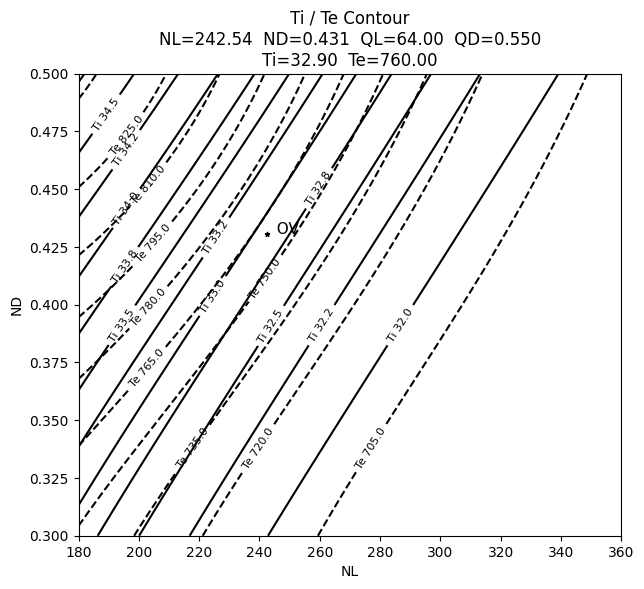

In [18]:


import numpy as np
import matplotlib.pyplot as plt


#下載W1W2.npz
#https://github.com/husthorng/Backpropagation_NN/blob/main/W1W2O.npz
w=np.load("/content/drive/MyDrive/W1W2O.npz")
W1 = w['W1']
W2 = w['W2']
OV=w['OV']
# -------------------------
# 建立 X0 X1 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 120)
x1 = np.linspace(min_v[1], max_v[1], 120)

X0, X1 = np.meshgrid(x0, x1)


# -------------------------
# 建立 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 80)
x1 = np.linspace(min_v[1], max_v[1], 80)

X0, X1 = np.meshgrid(x0, x1)

# 固定其他變數
x2 = OV[2]
x3 = OV[3]

grid = np.column_stack([
    X0.ravel(),
    X1.ravel(),
    np.full(X0.size, x2),
    np.full(X0.size, x3)
])

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# -------------------------
# NN prediction
# -------------------------

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
out = logistic(H @ W2)

# 反正規化
out_real = out * (max_v[4:6] - min_v[4:6]) + min_v[4:6]

Ti = out_real[:,0].reshape(X0.shape)
Te = out_real[:,1].reshape(X0.shape)

# -------------------------
# 畫等高線
# -------------------------
plt.figure(figsize=(7,6))

# Ti 實線
cs1 = plt.contour(X0, X1, Ti, levels=12, colors='black')
plt.clabel(cs1, fmt="Ti %.1f", fontsize=8)

# Te 虛線
cs2 = plt.contour(X0, X1, Te, levels=12, colors='black', linestyles='dashed')
plt.clabel(cs2, fmt="Te %.1f", fontsize=8)

# -------------------------
# 畫出指定點 (OV 的 NL, ND)
# -------------------------

x_point = OV[0]
y_point = OV[1]

plt.scatter(x_point, y_point, s=10, c='k', marker='*')
plt.text(x_point, y_point, "  OV", fontsize=11)

plt.xlabel("NL")
plt.ylabel("ND")

plt.title(
    f"Ti / Te Contour\n"
    f"NL={OV[0]:.2f}  ND={OV[1]:.3f}  QL={OV[2]:.2f}  QD={OV[3]:.3f}\n"
    f"Ti={OV[4]:.2f}  Te={OV[5]:.2f}"
)

plt.show()

plt.show()

In [ ]:
np.savez("/content/drive/MyDrive/W1W2O.npz", W1=W1, W2=W2, max_v=max_v, min_v=min_v,OV=OV)

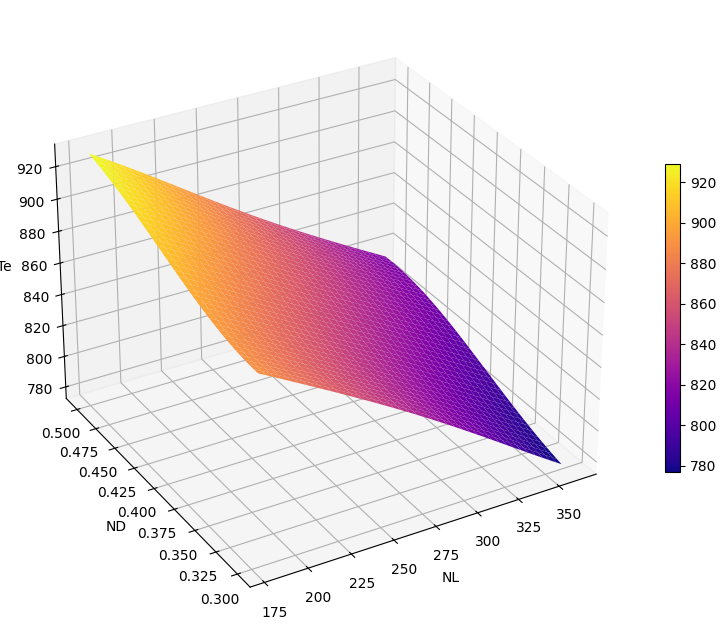

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#下載W1W2.npz
#https://github.com/husthorng/Backpropagation_NN/blob/main/W1W2O.npz
w=np.load("/content/drive/MyDrive/W1W2.npz")
W1 = w['W1']
W2 = w['W2']
# -------------------------
# 建立 X0 X1 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 120)
x1 = np.linspace(min_v[1], max_v[1], 120)

X0, X1 = np.meshgrid(x0, x1)

# -------------------------
# 固定其他變數
# -------------------------

x2 = (max_v[2]+min_v[2])/2
x3 = (max_v[3]+min_v[3])/2

# -------------------------
# 組成 NN input
# -------------------------

grid = np.zeros((X0.size,4))

grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = x2
grid[:,3] = x3

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

# 加 bias
Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# -------------------------
# NN Forward
# -------------------------

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))

out = logistic(H @ W2)

# -------------------------
# 反正規化
# -------------------------

OV = out * (max_v - min_v)[4:6] + min_v[4:6]

# 取 Te
Z = OV[:,1].reshape(X0.shape)

# -------------------------
# 畫 3D surface
# -------------------------

fig = plt.figure(figsize=(10,8))


ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X0,
    X1,
    Z,
    cmap='plasma',
    linewidth=0,
    antialiased=True
)


ax.set_xlabel("NL")
ax.set_ylabel("ND")
ax.set_zlabel("Te")

fig.colorbar(surf, shrink=0.5)

ax.view_init(elev=35, azim=-135)
ax.view_init(elev=30, azim=-120)
plt.show()

In [ ]:
OV

array([2.34452039e+02, 3.43163608e-01, 7.33382938e+01, 4.42793413e-01,
       3.64763772e+01, 8.00000000e+02])

In [ ]:
OV[2]

np.float64(73.33829377530552)

In [ ]:
x3

np.float64(0.45)

In [ ]:
oldOUT

array([[0.86256972, 0.66007021],
       [0.46400032, 0.46694502],
       [0.78863705, 0.73616234],
       [0.70499416, 0.71062178],
       [0.57504604, 0.45915153]])

In [ ]:
# ---------------- NN forward (VECTOR) ----------------
def evaluate(pop):
    x = (pop - range_V[1,0:4]) / (range_V[0,0:4]-range_V[1,0:4])
    X=X = np.hstack((x, np.ones((x.shape[0], 1))))
    h = logistic(X @ W1)
    H = np.hstack((h, np.ones((h.shape[0],1))))
    return logistic(H @ W2)

In [ ]:
OUT

array([[0.82783519, 0.89022376],
       [0.30630985, 0.29383303],
       [0.76525297, 0.82839477],
       [0.92087304, 0.96079312],
       [0.55402137, 0.73360561]])

In [ ]:
# ---------------- INITIAL POP ----------------
pop = range_V[1,0:4] + (range_V[0,0:4]-range_V[1,0:4])*np.random.rand(npop,nvar)

OUT = evaluate(pop)

oldpop = pop.copy()
oldOUT = OUT.copy()

NameError: name 'evaluate' is not defined

In [ ]:
CTe

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.33848872])

In [ ]:
range_V

array([[3.600000e+02, 5.000000e-01, 1.280000e+02, 5.500000e-01,
        5.042100e+01, 9.959671e+02],
       [1.800000e+02, 3.000000e-01, 6.400000e+01, 3.500000e-01,
        3.178824e+01, 6.982139e+02]])

In [ ]:
np.load("/content/drive/MyDrive/W1W2.npz")

NpzFile '/content/drive/MyDrive/W1W2.npz' with keys: W1, W2, max_v, min_v